In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import regionmask
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cmocean

from unseen import fileio

import utils

# Plot grid

In [2]:
infile = '/g/data/xv83/unseen-projects/outputs/bias/data/rx1day_AGCD-CSIRO_1901-2024_annual-jul-to-jun_AUS300i.nc'
ds = fileio.open_dataset(infile)
overlap_threshold = 0.67
shape_gpd = gpd.read_file('/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/australia/australia.shp')
shape_rgm = regionmask.from_geopandas(
    shape_gpd,
    names="AUS_NAME21",
    abbrevs="AUS_CODE21",
    name="australia"
)
frac = shape_rgm.mask_3D_frac_approx(ds)
mask = frac.sel(region=0) >= overlap_threshold

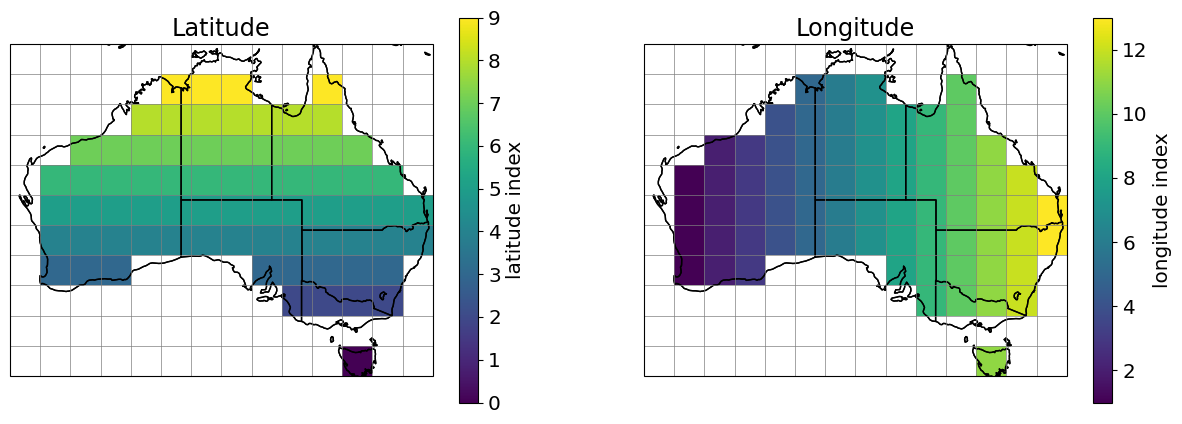

In [3]:
lon_array = xr.DataArray(
#    data=np.tile(mask.lon, (11, 1)),
    data=np.tile(np.arange(0,14), (11, 1)),
    coords={'lat': mask.lat, 'lon': mask.lon},
)

lat_array = xr.DataArray(
#    data=np.squeeze(np.dstack([mask.lat]*14)),
    data=np.squeeze(np.dstack([np.arange(0,11)]*14)),
    coords={'lat': mask.lat, 'lon': mask.lon},
) 

min_lat = mask.lat.values.min() - 1.5
max_lat = mask.lat.values.max() + 1.5
min_lon = mask.lon.values.min() - 1.5
max_lon = mask.lon.values.max() + 1.5

fig = plt.figure(figsize=[15, 5])

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
im1 = lat_array.where(mask).plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'latitude index'},
)
ax1.set_title('Latitude')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
im2 = lon_array.where(mask).plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'longitude index'},
)
ax2.set_title('Longitude')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

for lon in mask.lon.values:
    ax1.plot([lon - 1.5, lon - 1.5], [min_lat, max_lat], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
    ax2.plot([lon - 1.5, lon - 1.5], [min_lat, max_lat], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
for lat in mask.lat.values:
    ax1.plot([min_lon, max_lon], [lat - 1.5, lat - 1.5], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
    ax2.plot([min_lon, max_lon], [lat - 1.5, lat - 1.5], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)

plt.show()

# Plot rx1day data

In [11]:
return_period = 1000
infile = 'rx1day_spatial.nc'
ds_rx1day = xr.open_dataset(infile)

In [12]:
ds_rx1day

<xarray.Dataset> Size: 26kB
Dimensions:  (lev: 2, lat: 11, lon: 14)
Coordinates:
  * lev      (lev) int64 16B 100 1000
  * lat      (lat) float64 88B -42.0 -39.0 -36.0 -33.0 ... -18.0 -15.0 -12.0
  * lon      (lon) float64 112B 113.5 116.5 119.5 122.5 ... 146.5 149.5 152.5
Data variables:
    G2       (lev, lat, lon) float64 2kB ...
    M2       (lev, lat, lon) float64 2kB ...
    B2       (lev, lat, lon) float64 2kB ...
    T2       (lev, lat, lon) float64 2kB ...
    TMB2     (lev, lat, lon) float64 2kB ...
    OG2      (lev, lat, lon) float64 2kB ...
    OM2      (lev, lat, lon) float64 2kB ...
    OT2      (lev, lat, lon) float64 2kB ...
    MMM      (lev, lat, lon) float64 2kB ...
    obs      (lev, lat, lon) float64 2kB ...
    nmodels  (lat, lon) float64 1kB ...
Attributes:
    metric:   rx1day

In [13]:
m_tmb_ratio = ds_rx1day.sel({'lev': return_period})['M2'] / ds_rx1day.sel({'lev': return_period})['TMB2']

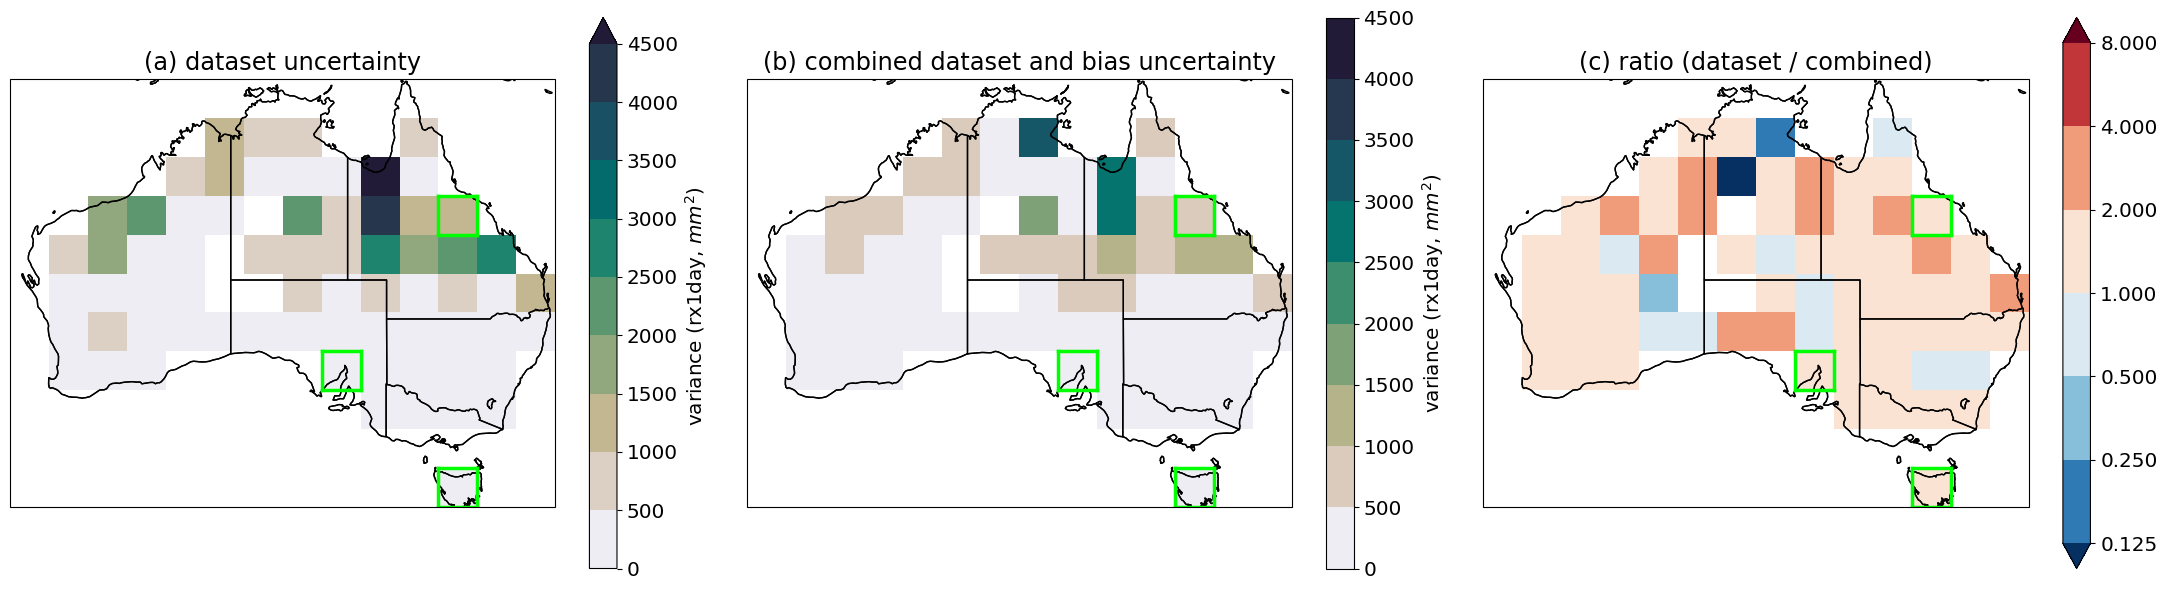

In [14]:
fig = plt.figure(figsize=[22, 6])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds_rx1day.sel({'lev': return_period})['M2'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (rx1day, $mm^2$)'},
    levels=np.arange(0, 5000, 500),
    cmap=cmocean.cm.rain,
)
ax1.set_title('(a) dataset uncertainty')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_rx1day.sel({'lev': return_period})['TMB2'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (rx1day, $mm^2$)'},
    levels=np.arange(0, 5000, 500),
    cmap=cmocean.cm.rain,
)
ax2.set_title('(b) combined dataset and bias uncertainty')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = m_tmb_ratio.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax3.set_title('(c) ratio (dataset / combined)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

utils.highlight_grid_box(ax1, 0, 11, color='lime')
utils.highlight_grid_box(ax1, 7, 11, color='lime')
utils.highlight_grid_box(ax1, 3, 8, color='lime')
utils.highlight_grid_box(ax2, 0, 11, color='lime')
utils.highlight_grid_box(ax2, 7, 11, color='lime')
utils.highlight_grid_box(ax2, 3, 8, color='lime')
utils.highlight_grid_box(ax3, 0, 11, color='lime')
utils.highlight_grid_box(ax3, 7, 11, color='lime')
utils.highlight_grid_box(ax3, 3, 8, color='lime')

plt.tight_layout()
plt.show()

In [15]:
mb = ds_rx1day.sel({'lev': return_period})['M2'] + ds_rx1day.sel({'lev': return_period})['B2']
mb_tmb_ratio = mb / ds_rx1day.sel({'lev': return_period})['TMB2']

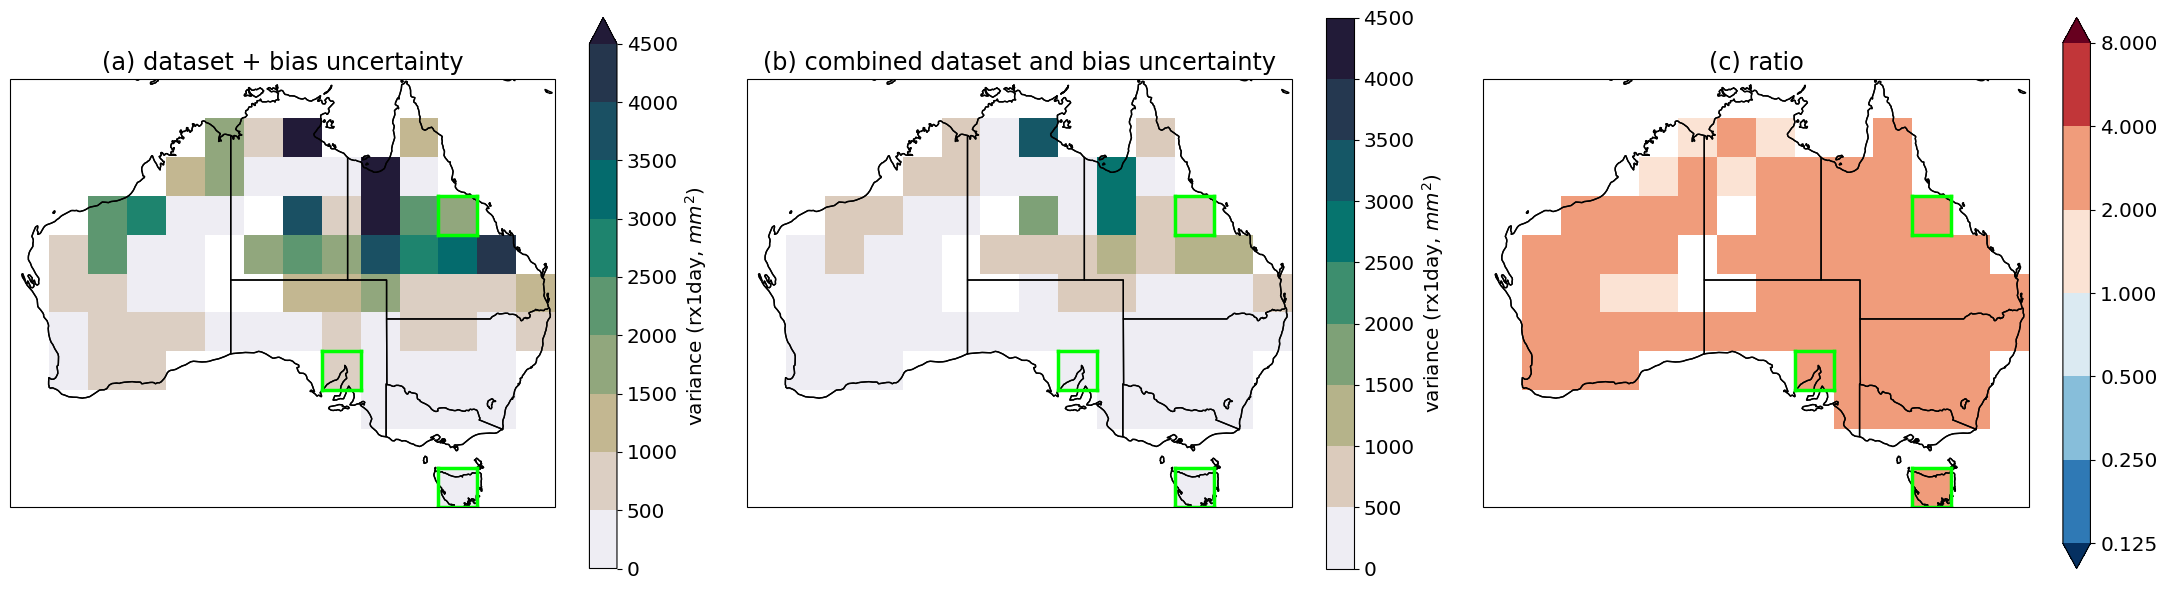

In [16]:
fig = plt.figure(figsize=[22, 6])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = mb.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (rx1day, $mm^2$)'},
    levels=np.arange(0, 5000, 500),
    cmap=cmocean.cm.rain,
)
ax1.set_title('(a) dataset + bias uncertainty')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_rx1day.sel({'lev': return_period})['TMB2'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (rx1day, $mm^2$)'},
    levels=np.arange(0, 5000, 500),
    cmap=cmocean.cm.rain,
)
ax2.set_title('(b) combined dataset and bias uncertainty')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = mb_tmb_ratio.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax3.set_title('(c) ratio')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

utils.highlight_grid_box(ax1, 0, 11, color='lime')
utils.highlight_grid_box(ax1, 7, 11, color='lime')
utils.highlight_grid_box(ax1, 3, 8, color='lime')
utils.highlight_grid_box(ax2, 0, 11, color='lime')
utils.highlight_grid_box(ax2, 7, 11, color='lime')
utils.highlight_grid_box(ax2, 3, 8, color='lime')
utils.highlight_grid_box(ax3, 0, 11, color='lime')
utils.highlight_grid_box(ax3, 7, 11, color='lime')
utils.highlight_grid_box(ax3, 3, 8, color='lime')

plt.tight_layout()
plt.show()

In [6]:
ratio_rx1day_obs = ds_rx1day.sel({'lev': return_period})['OG2'] / ds_rx1day.sel({'lev': return_period})['OM2']

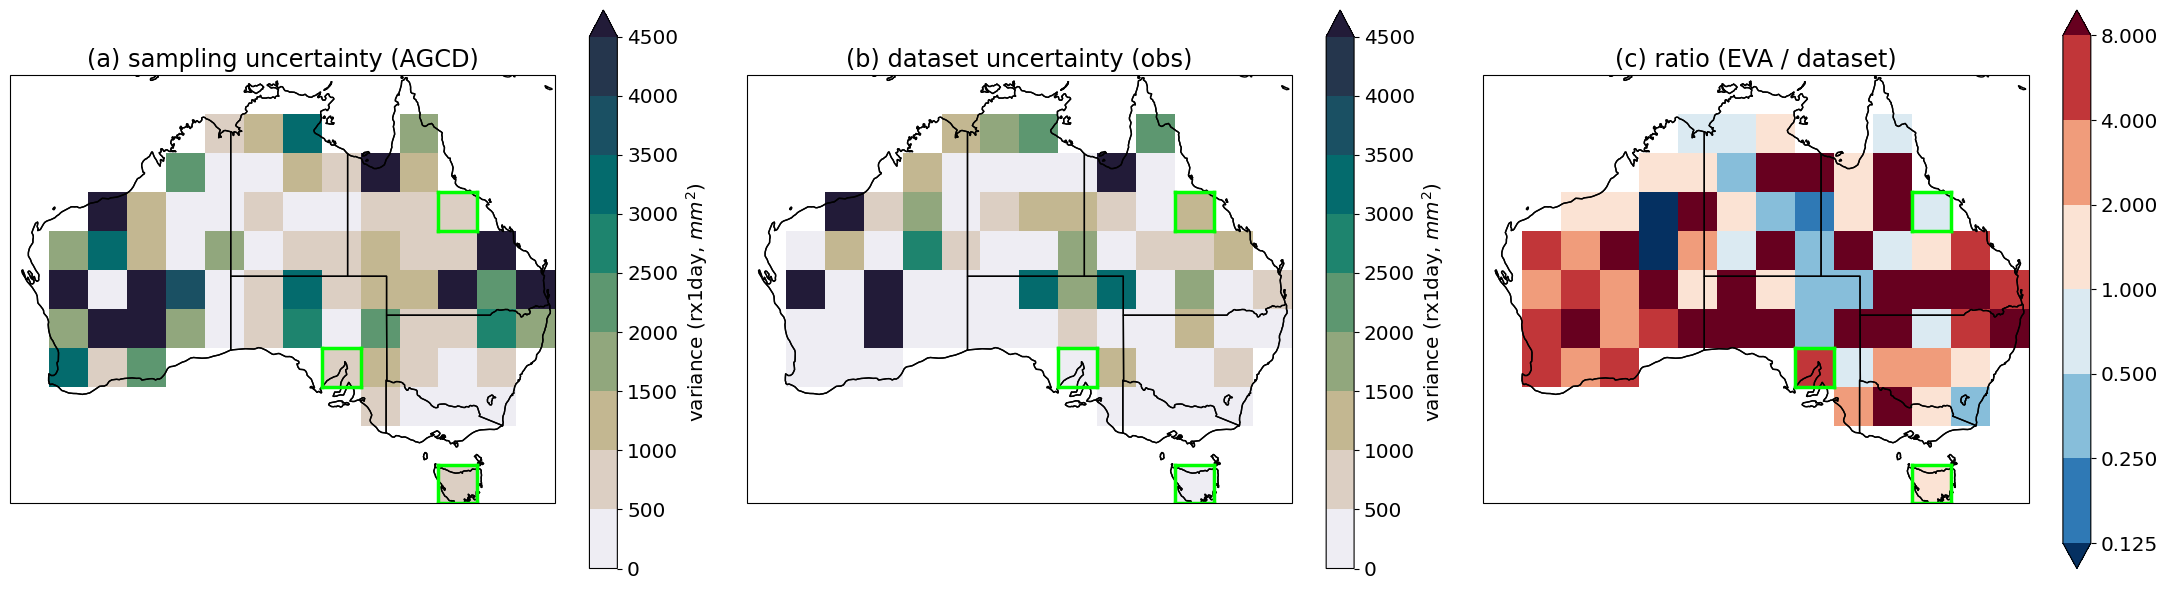

In [7]:
fig = plt.figure(figsize=[22, 6])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds_rx1day.sel({'lev': return_period})['OG2'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (rx1day, $mm^2$)'},
    levels=np.arange(0, 5000, 500),
    cmap=cmocean.cm.rain,
)
ax1.set_title('(a) sampling uncertainty (AGCD)')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_rx1day.sel({'lev': return_period})['OM2'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (rx1day, $mm^2$)'},
    levels=np.arange(0, 5000, 500),
    cmap=cmocean.cm.rain,
)
ax2.set_title('(b) dataset uncertainty (obs)')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = ratio_rx1day_obs.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax3.set_title('(c) ratio (EVA / dataset)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

utils.highlight_grid_box(ax1, 0, 11, color='lime')
utils.highlight_grid_box(ax1, 7, 11, color='lime')
utils.highlight_grid_box(ax1, 3, 8, color='lime')
utils.highlight_grid_box(ax2, 0, 11, color='lime')
utils.highlight_grid_box(ax2, 7, 11, color='lime')
utils.highlight_grid_box(ax2, 3, 8, color='lime')
utils.highlight_grid_box(ax3, 0, 11, color='lime')
utils.highlight_grid_box(ax3, 7, 11, color='lime')
utils.highlight_grid_box(ax3, 3, 8, color='lime')

plt.tight_layout()
plt.show()

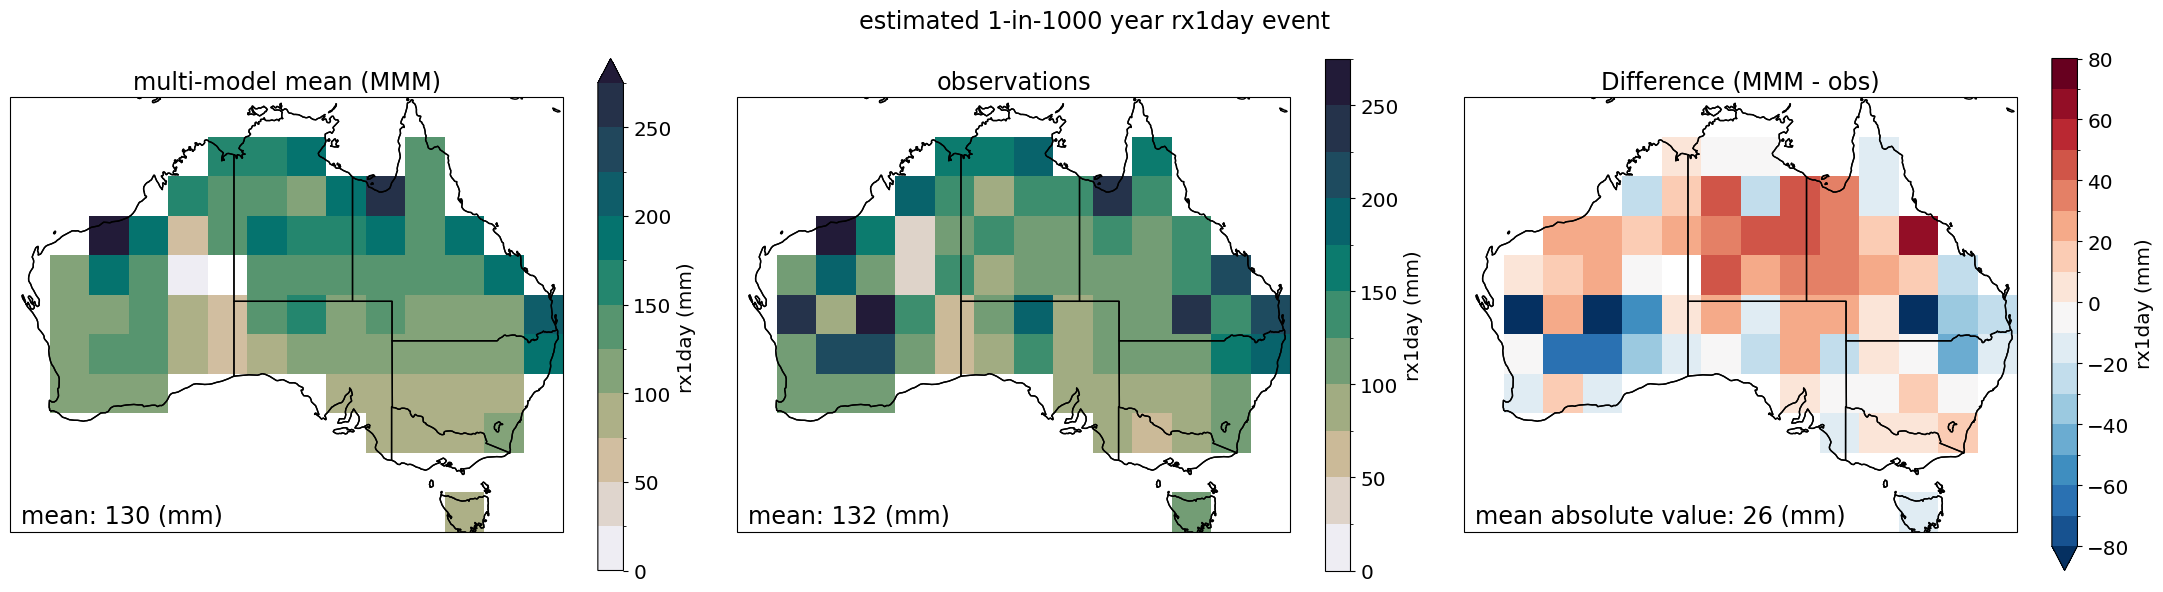

In [8]:
fig = plt.figure(figsize=[22, 6])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds_rx1day.sel({'lev': return_period})['MMM'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'rx1day (mm)'},
    levels=np.arange(0, 276, 25),
    cmap=cmocean.cm.rain,
)
ax1.set_title('multi-model mean (MMM)')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
mmm_mean = float(ds_rx1day.sel({'lev': return_period})['MMM'].mean())
ax1.text(0.02, 0.02, f'mean: {mmm_mean:.0f} (mm)', transform=ax1.transAxes, fontsize='xx-large')

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_rx1day.sel({'lev': return_period})['obs'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'rx1day (mm)'},
    levels=np.arange(0, 276, 25),
    cmap=cmocean.cm.rain,
)
ax2.set_title('observations')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
obs_mean = float(ds_rx1day.sel({'lev': return_period})['obs'].mean())
ax2.text(0.02, 0.02, f'mean: {obs_mean:.0f} (mm)', transform=ax2.transAxes, fontsize='xx-large')

diff = ds_rx1day.sel({'lev': return_period})['MMM'] - ds_rx1day.sel({'lev': return_period})['obs']
ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = diff.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'rx1day (mm)'},
    levels=[-80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 80],
    cmap='RdBu_r',
)
ax3.set_title('Difference (MMM - obs)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)
diff_abs_mean = float(np.abs(diff).mean())
ax3.text(0.02, 0.02, f'mean absolute value: {diff_abs_mean:.0f} (mm)', transform=ax3.transAxes, fontsize='xx-large')

plt.suptitle(f'estimated 1-in-{return_period} year rx1day event', fontsize='xx-large')
plt.tight_layout()
plt.show()

In [9]:
ratio_rx1day = ds_rx1day.sel({'lev': return_period})['T2'] / ds_rx1day.sel({'lev': return_period})['OT2']

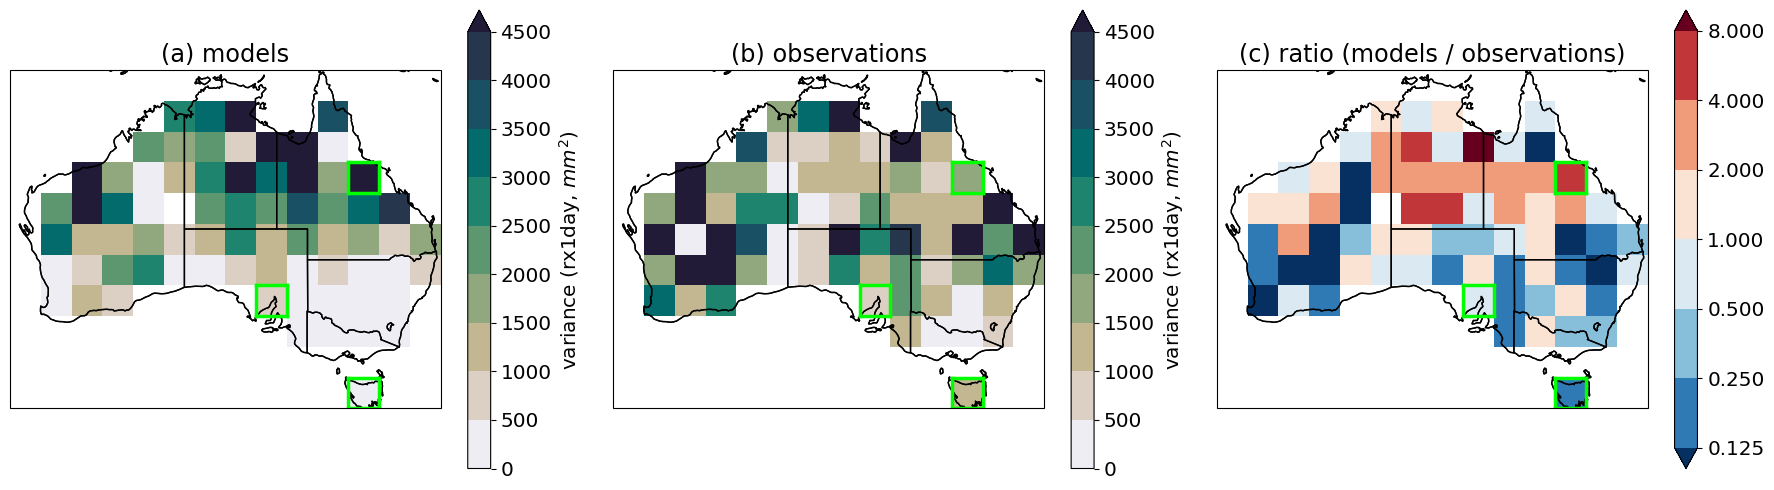

In [10]:
fig = plt.figure(figsize=[18, 5])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds_rx1day.sel({'lev': return_period})['T2'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (rx1day, $mm^2$)'},
    levels=np.arange(0, 5000, 500),
    extend='max',
    cmap=cmocean.cm.rain,
)
ax1.set_title('(a) models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_rx1day.sel({'lev': return_period})['OT2'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (rx1day, $mm^2$)'},
    levels=np.arange(0, 5000, 500),
    extend='max',
    cmap=cmocean.cm.rain,
)
ax2.set_title('(b) observations')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
obs_mean = float(ds_rx1day.sel({'lev': return_period})['OT2'].mean())

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = ratio_rx1day.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax3.set_title('(c) ratio (models / observations)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

utils.highlight_grid_box(ax1, 0, 11, color='lime')
utils.highlight_grid_box(ax1, 7, 11, color='lime')
utils.highlight_grid_box(ax1, 3, 8, color='lime')
utils.highlight_grid_box(ax2, 0, 11, color='lime')
utils.highlight_grid_box(ax2, 7, 11, color='lime')
utils.highlight_grid_box(ax2, 3, 8, color='lime')
utils.highlight_grid_box(ax3, 0, 11, color='lime')
utils.highlight_grid_box(ax3, 7, 11, color='lime')
utils.highlight_grid_box(ax3, 3, 8, color='lime')

#plt.suptitle(f'uncertainty in the estimated 1-in-{return_period} year rx1day event', fontsize='xx-large')
plt.tight_layout()
plt.savefig('figures/rx1day_total_uncertainty_map.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

In [11]:
mmm_mean = float(ds_rx1day.sel({'lev': return_period})['T2'].mean())
obs_mean = float(ds_rx1day.sel({'lev': return_period})['OT2'].mean())
mean_ratio = mmm_mean / obs_mean

print(f'MMM mean uncertainty: {mmm_mean:.1f} mm^2')
print(f'Obs mean uncertainty: {obs_mean:.1f} mm^2')
print(f'Ratio: {mean_ratio:.2f}')

MMM mean uncertainty: 2184.1 mm^2
Obs mean uncertainty: 3460.8 mm^2
Ratio: 0.63


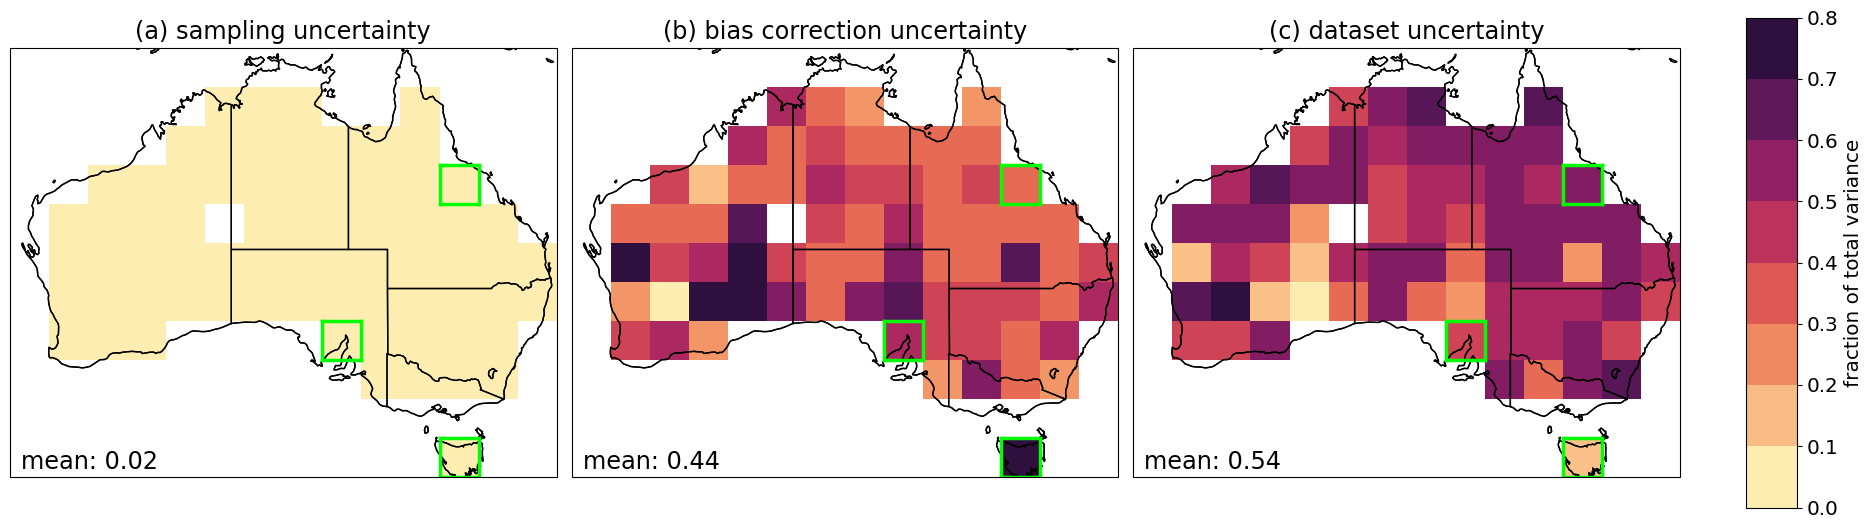

In [12]:
fig = plt.figure(figsize=[17, 7])
cbar_levels = np.arange(0, 0.81, 0.1)
cmap = cmocean.cm.matter

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
g_frac = ds_rx1day.sel({'lev': return_period})['G2'] / ds_rx1day.sel({'lev': return_period})['T2']
im1 = g_frac.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax1.set_title('(a) sampling uncertainty')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
g_mean = float(g_frac.mean())
ax1.text(0.02, 0.02, f'mean: {g_mean:.2f}', transform=ax1.transAxes, fontsize='xx-large')

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
b_frac = ds_rx1day.sel({'lev': return_period})['B2'] / ds_rx1day.sel({'lev': return_period})['T2']
im2 = b_frac.plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax2.set_title('(b) bias correction uncertainty')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
b_mean = float(b_frac.mean())
ax2.text(0.02, 0.02, f'mean: {b_mean:.2f}', transform=ax2.transAxes, fontsize='xx-large')

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
m_frac = ds_rx1day.sel({'lev': return_period})['M2'] / ds_rx1day.sel({'lev': return_period})['T2']
im3 = m_frac.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax3.set_title('(c) dataset uncertainty')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)
m_mean = float(m_frac.mean())
ax3.text(0.02, 0.02, f'mean: {m_mean:.2f}', transform=ax3.transAxes, fontsize='xx-large')

utils.highlight_grid_box(ax1, 0, 11, color='lime')
utils.highlight_grid_box(ax1, 7, 11, color='lime')
utils.highlight_grid_box(ax1, 3, 8, color='lime')
utils.highlight_grid_box(ax2, 0, 11, color='lime')
utils.highlight_grid_box(ax2, 7, 11, color='lime')
utils.highlight_grid_box(ax2, 3, 8, color='lime')
utils.highlight_grid_box(ax3, 0, 11, color='lime')
utils.highlight_grid_box(ax3, 7, 11, color='lime')
utils.highlight_grid_box(ax3, 3, 8, color='lime')

cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
fig.colorbar(im1, cax=cbar_ax, label='fraction of total variance')

#plt.suptitle(f' uncertainty in the estimated 1-in-{return_period} year rx1day event', fontsize='xx-large')
plt.tight_layout()
plt.savefig('figures/rx1day_component_uncertainty_map.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

In [13]:
g_max = float(g_frac.max())
g_mean = float(g_frac.mean())
g_min = float(g_frac.min())

print(f'sampling uncertainty maximum: {g_max:.3f}')
print(f'sampling uncertainty mean: {g_mean:.3f}')
print(f'sampling uncertainty minimum: {g_min:.3f}')

sampling uncertainty maximum: 0.060
sampling uncertainty mean: 0.016
sampling uncertainty minimum: 0.004


In [14]:
b_max = float(b_frac.max())
b_mean = float(b_frac.mean())
b_min = float(b_frac.min())

print(f'bias correction uncertainty maximum: {b_max:.2f}')
print(f'bias correction uncertainty mean: {b_mean:.2f}')
print(f'bias correction uncertainty minimum: {b_min:.2f}')

bias correction uncertainty maximum: 0.93
bias correction uncertainty mean: 0.44
bias correction uncertainty minimum: 0.02


In [15]:
m_max = float(m_frac.max())
m_mean = float(m_frac.mean())
m_min = float(m_frac.min())

print(f'model uncertainty maximum: {m_max:.2f}')
print(f'model uncertainty mean: {m_mean:.2f}')
print(f'model uncertainty minimum: {m_min:.2f}')

model uncertainty maximum: 0.92
model uncertainty mean: 0.54
model uncertainty minimum: 0.06


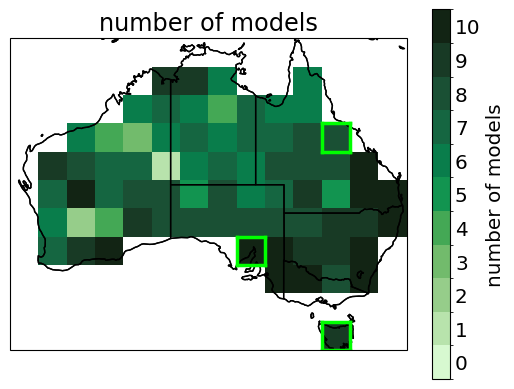

In [16]:
fig = plt.figure()#figsize=[5, 5])

ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
im1 = ds_rx1day['nmodels'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    cbar_kwargs={'label': ' '},
    levels=np.arange(-0.5, 10.6, 1.0),
#    extend='min',
    cmap=cmocean.cm.algae
)
ax1.set_title('number of models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

cbar = fig.colorbar(im1, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], label='number of models')
cbar.ax.tick_params(size=0)

utils.highlight_grid_box(ax1, 0, 11, color='lime')
utils.highlight_grid_box(ax1, 7, 11, color='lime')
utils.highlight_grid_box(ax1, 3, 8, color='lime')

plt.show()

## Plot txx data

In [4]:
return_period = 1000
infile = 'txx_spatial.nc'
ds_txx = xr.open_dataset(infile)

In [5]:
m_tmb_ratio = ds_txx.sel({'lev': return_period})['M2'] / ds_txx.sel({'lev': return_period})['TMB2']

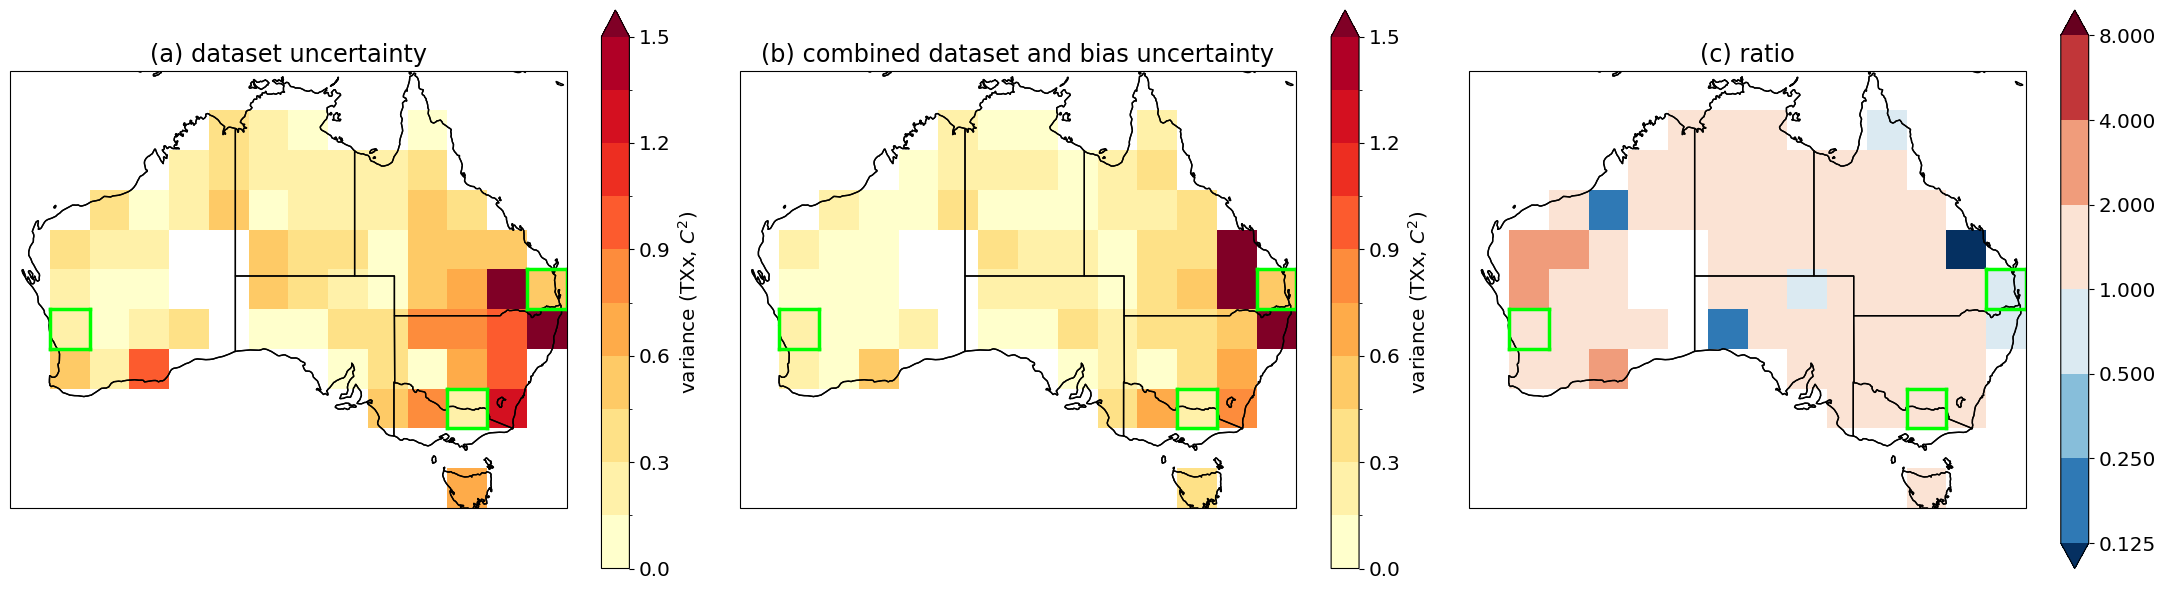

In [10]:
fig = plt.figure(figsize=[22, 6])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds_txx.sel({'lev': return_period})['M2'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (TXx, $C^2$)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax1.set_title('(a) dataset uncertainty')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_txx.sel({'lev': return_period})['TMB2'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (TXx, $C^2$)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax2.set_title('(b) combined dataset and bias uncertainty')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = m_tmb_ratio.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax3.set_title('(c) ratio')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

utils.highlight_grid_box(ax1, 5, 13, color='lime')
utils.highlight_grid_box(ax1, 2, 11, color='lime')
utils.highlight_grid_box(ax1, 4, 1, color='lime')

utils.highlight_grid_box(ax2, 5, 13, color='lime')
utils.highlight_grid_box(ax2, 2, 11, color='lime')
utils.highlight_grid_box(ax2, 4, 1, color='lime')

utils.highlight_grid_box(ax3, 5, 13, color='lime')
utils.highlight_grid_box(ax3, 2, 11, color='lime')
utils.highlight_grid_box(ax3, 4, 1, color='lime')

plt.tight_layout()
plt.show()

In [8]:
mb = ds_txx.sel({'lev': return_period})['M2'] + ds_txx.sel({'lev': return_period})['B2']
mb_tmb_ratio = mb / ds_txx.sel({'lev': return_period})['TMB2']

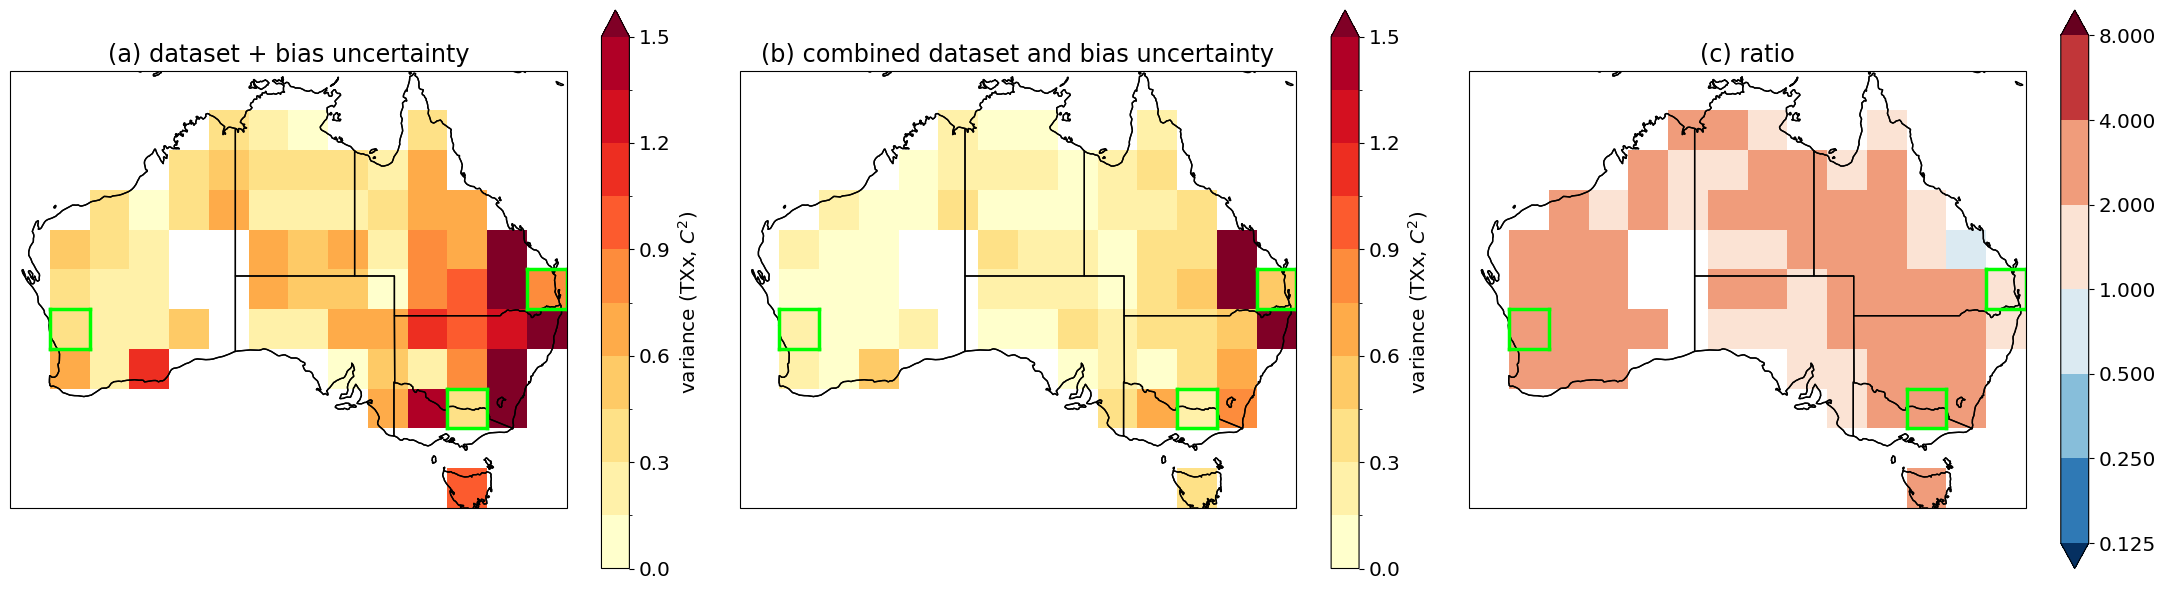

In [9]:
fig = plt.figure(figsize=[22, 6])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = mb.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (TXx, $C^2$)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax1.set_title('(a) dataset + bias uncertainty')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_txx.sel({'lev': return_period})['TMB2'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (TXx, $C^2$)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax2.set_title('(b) combined dataset and bias uncertainty')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = mb_tmb_ratio.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax3.set_title('(c) ratio')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

utils.highlight_grid_box(ax1, 5, 13, color='lime')
utils.highlight_grid_box(ax1, 2, 11, color='lime')
utils.highlight_grid_box(ax1, 4, 1, color='lime')

utils.highlight_grid_box(ax2, 5, 13, color='lime')
utils.highlight_grid_box(ax2, 2, 11, color='lime')
utils.highlight_grid_box(ax2, 4, 1, color='lime')

utils.highlight_grid_box(ax3, 5, 13, color='lime')
utils.highlight_grid_box(ax3, 2, 11, color='lime')
utils.highlight_grid_box(ax3, 4, 1, color='lime')

plt.tight_layout()
plt.show()

In [18]:
ratio_txx_obs = ds_txx.sel({'lev': return_period})['OG2'] / ds_txx.sel({'lev': return_period})['OM2']

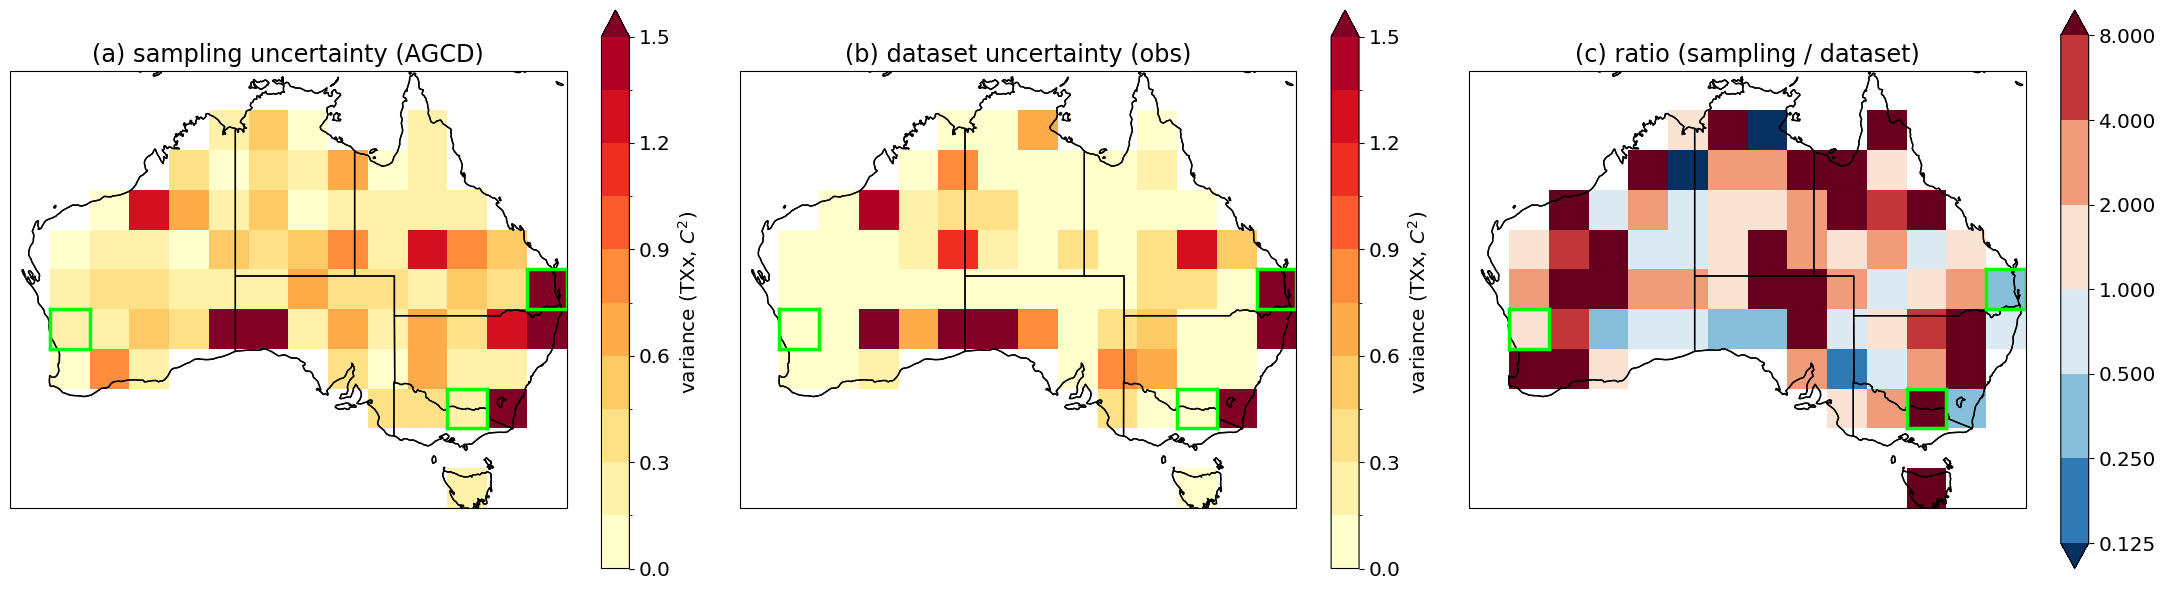

In [19]:
fig = plt.figure(figsize=[22, 6])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds_txx.sel({'lev': return_period})['OG2'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (TXx, $C^2$)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax1.set_title('(a) sampling uncertainty (AGCD)')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_txx.sel({'lev': return_period})['OM2'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (TXx, $C^2$)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax2.set_title('(b) dataset uncertainty (obs)')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = ratio_txx_obs.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax3.set_title('(c) ratio (sampling / dataset)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

utils.highlight_grid_box(ax1, 5, 13, color='lime')
utils.highlight_grid_box(ax1, 2, 11, color='lime')
utils.highlight_grid_box(ax1, 4, 1, color='lime')

utils.highlight_grid_box(ax2, 5, 13, color='lime')
utils.highlight_grid_box(ax2, 2, 11, color='lime')
utils.highlight_grid_box(ax2, 4, 1, color='lime')

utils.highlight_grid_box(ax3, 5, 13, color='lime')
utils.highlight_grid_box(ax3, 2, 11, color='lime')
utils.highlight_grid_box(ax3, 4, 1, color='lime')

plt.tight_layout()
plt.show()

In [20]:
ds_txx.sel({'lev': return_period})['OG2'].values[5, 3]

np.float64(0.33620737030426756)

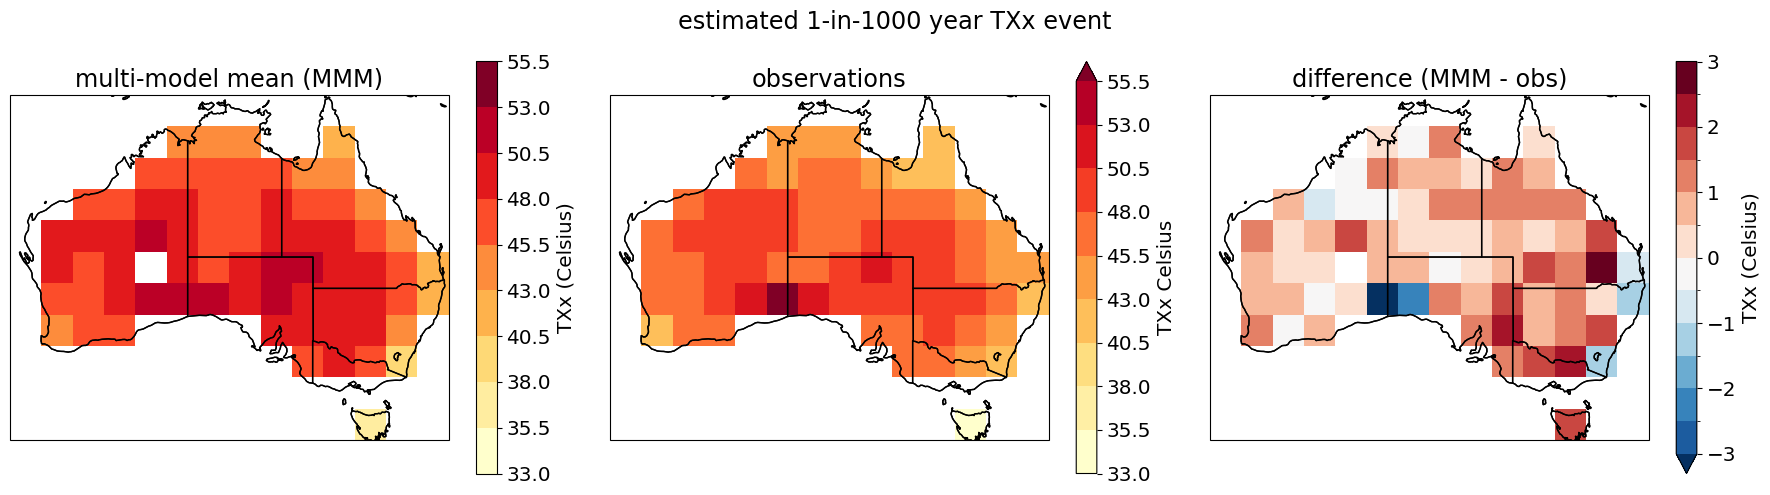

In [21]:
fig = plt.figure(figsize=[18, 5])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds_txx.sel({'lev': return_period})['MMM'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'TXx (Celsius)'},
    levels=np.arange(33, 56, 2.5),
    cmap='YlOrRd',
)
ax1.set_title('multi-model mean (MMM)')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_txx.sel({'lev': return_period})['obs'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'TXx Celsius'},
    levels=np.arange(33, 56, 2.5),
    cmap='YlOrRd',
)
ax2.set_title('observations')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

diff = ds_txx.sel({'lev': return_period})['MMM'] - ds_txx.sel({'lev': return_period})['obs']
ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = diff.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'TXx (Celsius)'},
    levels=[-3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
    cmap='RdBu_r',
)
ax3.set_title('difference (MMM - obs)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

plt.suptitle(f'estimated 1-in-{return_period} year TXx event', fontsize='xx-large')
plt.tight_layout()
plt.show()

In [22]:
ds_txx.sel({'lev': return_period})['MMM'].values[5, 0]

np.float64(nan)

In [23]:
diff_abs_mean = float(np.abs(diff).mean())

mmm_mean = float(ds_txx.sel({'lev': return_period})['MMM'].mean())
obs_mean = float(ds_txx.sel({'lev': return_period})['obs'].mean())

print(f'MMM mean: {mmm_mean:.1f} C')
print(f'Obs mean: {obs_mean:.1f} C')
print(f'Mean absolute difference: {diff_abs_mean:.1f} C')

MMM mean: 47.5 C
Obs mean: 47.0 C
Mean absolute difference: 1.0 C


In [24]:
ratio_txx = ds_txx.sel({'lev': return_period})['T2'] / ds_txx.sel({'lev': return_period})['OT2']

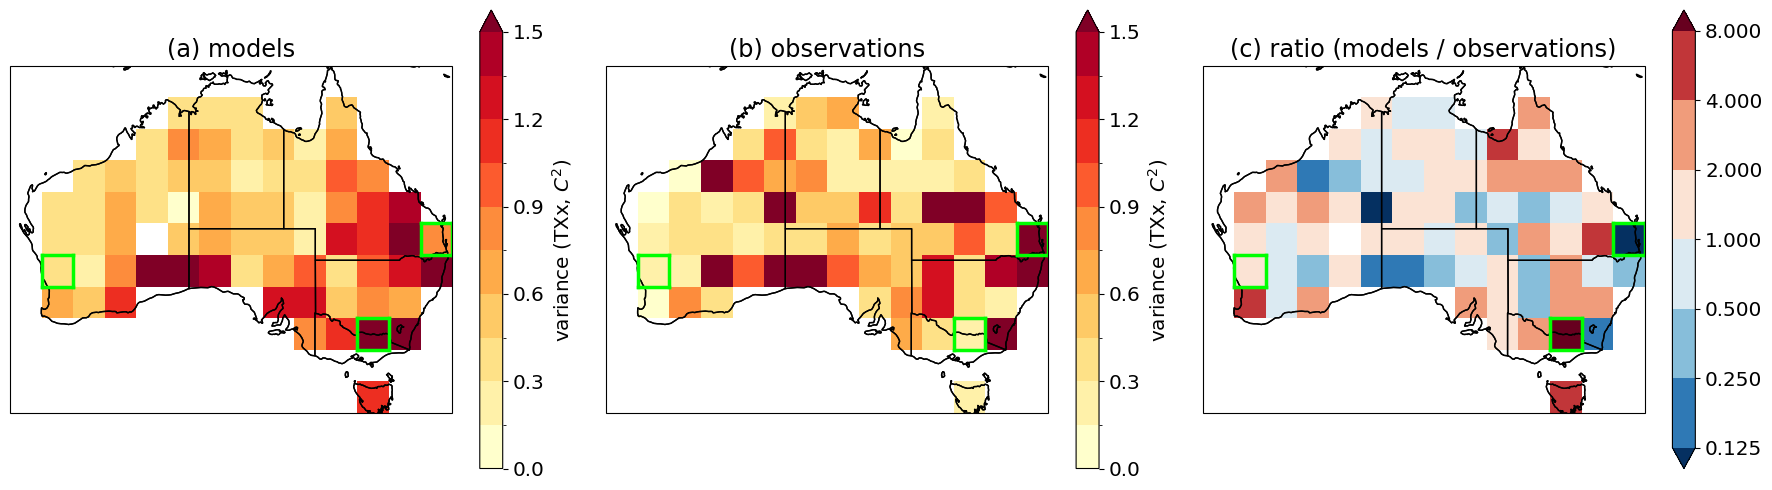

In [25]:
fig = plt.figure(figsize=[18, 5])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds_txx.sel({'lev': return_period})['T2'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (TXx, $C^2$)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax1.set_title('(a) models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_txx.sel({'lev': return_period})['OT2'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (TXx, $C^2$)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax2.set_title('(b) observations')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = ratio_txx.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax3.set_title('(c) ratio (models / observations)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

utils.highlight_grid_box(ax1, 5, 13, color='lime')
utils.highlight_grid_box(ax1, 2, 11, color='lime')
utils.highlight_grid_box(ax1, 4, 1, color='lime')

utils.highlight_grid_box(ax2, 5, 13, color='lime')
utils.highlight_grid_box(ax2, 2, 11, color='lime')
utils.highlight_grid_box(ax2, 4, 1, color='lime')

utils.highlight_grid_box(ax3, 5, 13, color='lime')
utils.highlight_grid_box(ax3, 2, 11, color='lime')
utils.highlight_grid_box(ax3, 4, 1, color='lime')

#plt.suptitle(f'uncertainty in the estimated 1-in-{return_period} year TXx event', fontsize='xx-large')
plt.tight_layout()
plt.savefig('figures/txx_total_uncertainty_map.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

In [26]:
mmm_mean = float(ds_txx.sel({'lev': return_period})['T2'].mean())
obs_mean = float(ds_txx.sel({'lev': return_period})['OT2'].mean())
mean_ratio = mmm_mean / obs_mean

print(f'MMM mean uncertainty: {mmm_mean:.1f} C^2')
print(f'Obs mean uncertainty: {obs_mean:.1f} C^2')
print(f'Ratio: {mean_ratio:.2f}')

MMM mean uncertainty: 0.8 C^2
Obs mean uncertainty: 1.6 C^2
Ratio: 0.54


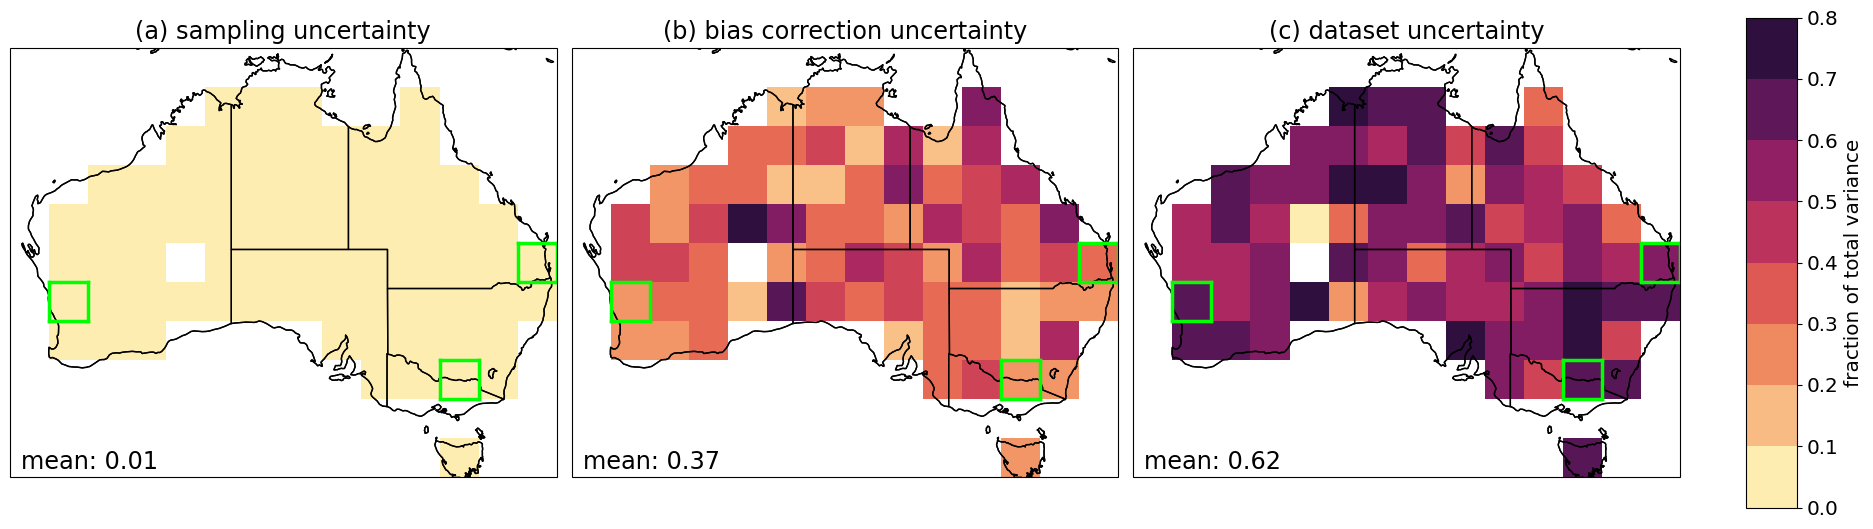

In [27]:
fig = plt.figure(figsize=[17, 7])
cbar_levels = np.arange(0, 0.81, 0.1)
cmap = cmocean.cm.matter

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
g_frac = ds_txx.sel({'lev': return_period})['G2'] / ds_txx.sel({'lev': return_period})['T2'] 
im1 = g_frac.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax1.set_title('(a) sampling uncertainty')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
g_mean = float(g_frac.mean())
ax1.text(0.02, 0.02, f'mean: {g_mean:.2f}', transform=ax1.transAxes, fontsize='xx-large')

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
b_frac = ds_txx.sel({'lev': return_period})['B2'] / ds_txx.sel({'lev': return_period})['T2']
im2 = b_frac.plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax2.set_title('(b) bias correction uncertainty')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
b_mean = float(b_frac.mean())
ax2.text(0.02, 0.02, f'mean: {b_mean:.2f}', transform=ax2.transAxes, fontsize='xx-large')

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
m_frac = ds_txx.sel({'lev': return_period})['M2'] / ds_txx.sel({'lev': return_period})['T2']
im3 = m_frac.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax3.set_title('(c) dataset uncertainty')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)
m_mean = float(m_frac.mean())
ax3.text(0.02, 0.02, f'mean: {m_mean:.2f}', transform=ax3.transAxes, fontsize='xx-large')

cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
fig.colorbar(im1, cax=cbar_ax, label='fraction of total variance')

utils.highlight_grid_box(ax1, 5, 13, color='lime')
utils.highlight_grid_box(ax1, 2, 11, color='lime')
utils.highlight_grid_box(ax1, 4, 1, color='lime')

utils.highlight_grid_box(ax2, 5, 13, color='lime')
utils.highlight_grid_box(ax2, 2, 11, color='lime')
utils.highlight_grid_box(ax2, 4, 1, color='lime')

utils.highlight_grid_box(ax3, 5, 13, color='lime')
utils.highlight_grid_box(ax3, 2, 11, color='lime')
utils.highlight_grid_box(ax3, 4, 1, color='lime')

#plt.suptitle(f' uncertainty in the estimated 1-in-{return_period} year Txx event', fontsize='xx-large')
plt.tight_layout()
plt.savefig('figures/txx_component_uncertainty_map.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

In [28]:
g_max = float(g_frac.max())
g_mean = float(g_frac.mean())
g_min = float(g_frac.min())

print(f'sampling uncertainty maximum: {g_max:.3f}')
print(f'sampling uncertainty mean: {g_mean:.3f}')
print(f'sampling uncertainty minimum: {g_min:.3f}')

sampling uncertainty maximum: 0.056
sampling uncertainty mean: 0.013
sampling uncertainty minimum: 0.001


In [29]:
b_max = float(b_frac.max())
b_mean = float(b_frac.mean())
b_min = float(b_frac.min())

print(f'bias correction uncertainty maximum: {b_max:.2f}')
print(f'bias correction uncertainty mean: {b_mean:.2f}')
print(f'bias correction uncertainty minimum: {b_min:.2f}')

bias correction uncertainty maximum: 0.99
bias correction uncertainty mean: 0.37
bias correction uncertainty minimum: 0.13


In [30]:
m_max = float(m_frac.max())
m_mean = float(m_frac.mean())
m_min = float(m_frac.min())

print(f'model uncertainty maximum: {m_max:.2f}')
print(f'model uncertainty mean: {m_mean:.2f}')
print(f'model uncertainty minimum: {m_min:.2f}')

model uncertainty maximum: 0.87
model uncertainty mean: 0.62
model uncertainty minimum: 0.00


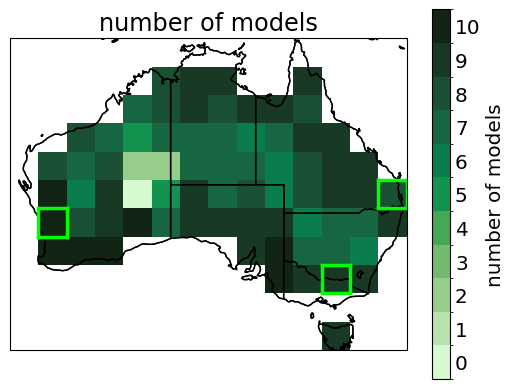

In [31]:
fig = plt.figure()#figsize=[5, 5])

ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
im1 = ds_txx['nmodels'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    cbar_kwargs={'label': ' '},
    levels=np.arange(-0.5, 10.6, 1.0),
#    extend='min',
    cmap=cmocean.cm.algae
)
ax1.set_title('number of models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

cbar = fig.colorbar(im1, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], label='number of models')
cbar.ax.tick_params(size=0)

utils.highlight_grid_box(ax1, 5, 13, color='lime')
utils.highlight_grid_box(ax1, 2, 11, color='lime')
utils.highlight_grid_box(ax1, 4, 1, color='lime')

plt.show()

## Combined

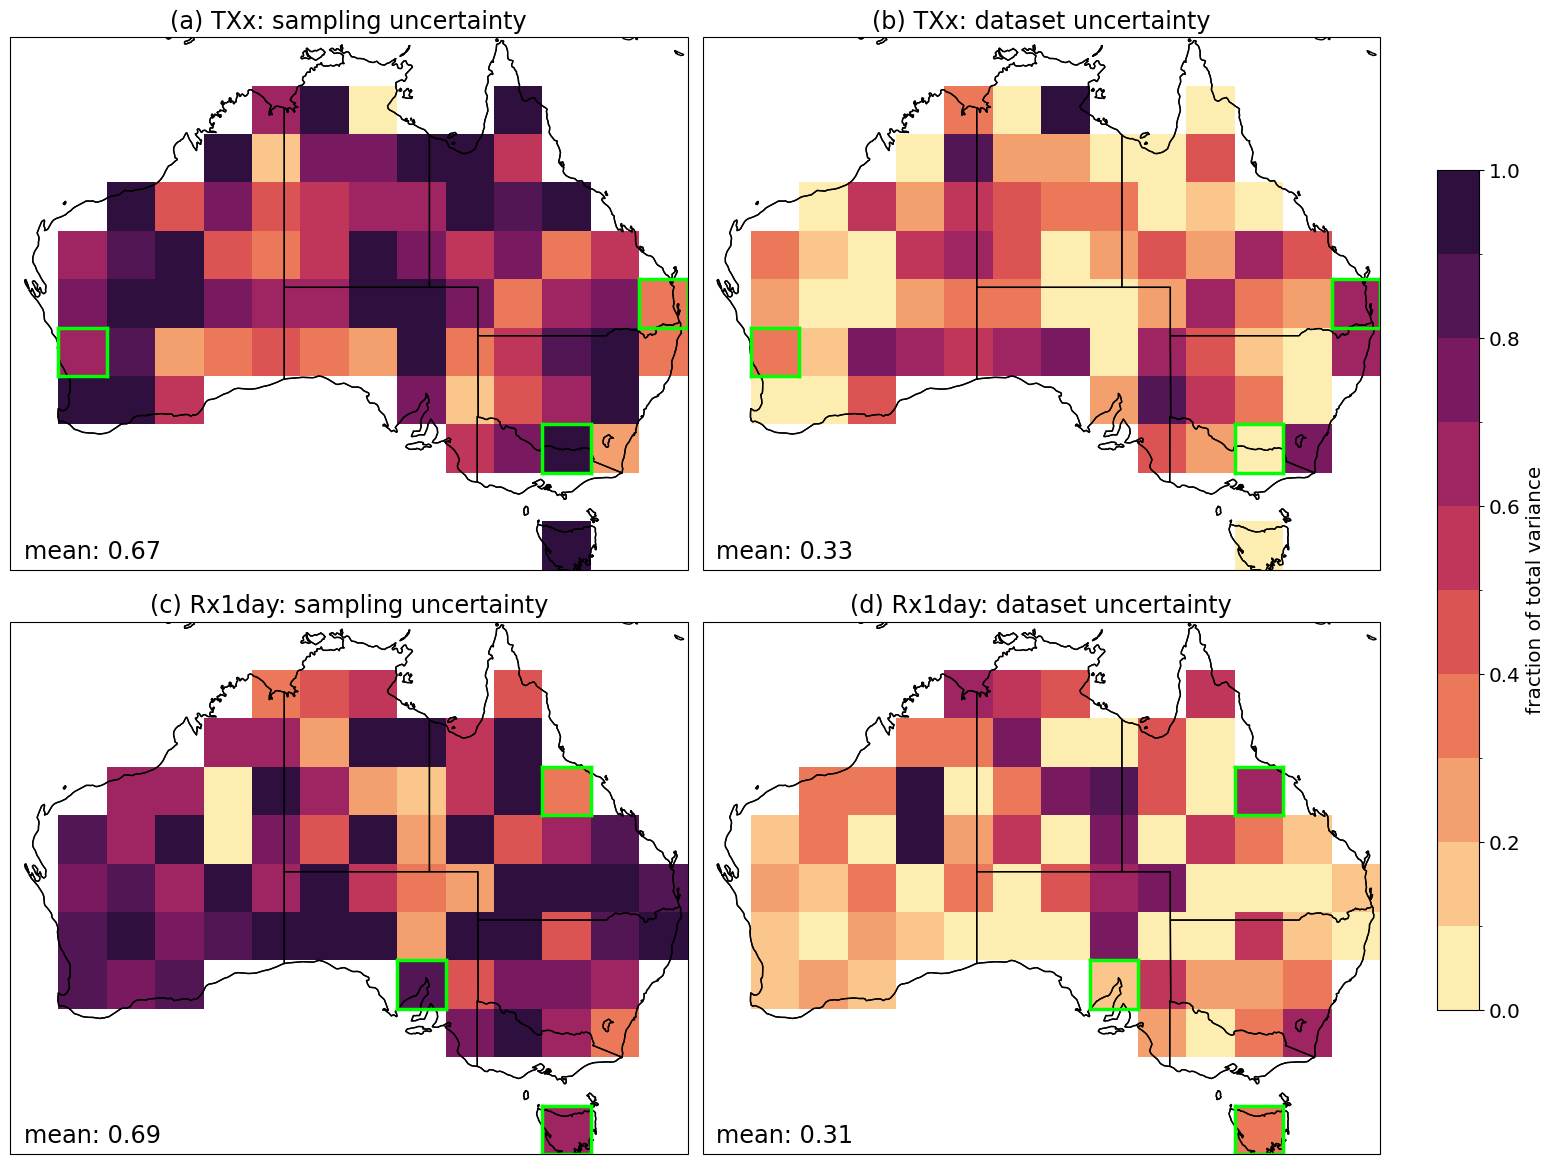

In [40]:
fig = plt.figure(figsize=[14, 12])
cbar_levels = np.arange(0, 1.01, 0.1)
cmap = cmocean.cm.matter

ax1 = fig.add_subplot(221, projection=ccrs.PlateCarree())
og_frac = ds_txx.sel({'lev': return_period})['OG2'] / ds_txx.sel({'lev': return_period})['OT2'] 
im1 = og_frac.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax1.set_title('(a) TXx: sampling uncertainty')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
og_mean = float(og_frac.mean())
ax1.text(0.02, 0.02, f'mean: {og_mean:.2f}', transform=ax1.transAxes, fontsize='xx-large')

ax2 = fig.add_subplot(222, projection=ccrs.PlateCarree())
om_frac = ds_txx.sel({'lev': return_period})['OM2'] / ds_txx.sel({'lev': return_period})['OT2']
im2 = om_frac.plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax2.set_title('(b) TXx: dataset uncertainty')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
om_mean = float(om_frac.mean())
ax2.text(0.02, 0.02, f'mean: {om_mean:.2f}', transform=ax2.transAxes, fontsize='xx-large')

cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
fig.colorbar(im1, cax=cbar_ax, label='fraction of total variance')

utils.highlight_grid_box(ax1, 5, 13, color='lime')
utils.highlight_grid_box(ax1, 2, 11, color='lime')
utils.highlight_grid_box(ax1, 4, 1, color='lime')
utils.highlight_grid_box(ax2, 5, 13, color='lime')
utils.highlight_grid_box(ax2, 2, 11, color='lime')
utils.highlight_grid_box(ax2, 4, 1, color='lime')


ax3 = fig.add_subplot(223, projection=ccrs.PlateCarree())
og_frac = ds_rx1day.sel({'lev': return_period})['OG2'] / ds_rx1day.sel({'lev': return_period})['OT2']
im3 = og_frac.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax3.set_title('(c) Rx1day: sampling uncertainty')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)
og_mean = float(og_frac.mean())
ax3.text(0.02, 0.02, f'mean: {og_mean:.2f}', transform=ax3.transAxes, fontsize='xx-large')

ax4 = fig.add_subplot(224, projection=ccrs.PlateCarree())
om_frac = ds_rx1day.sel({'lev': return_period})['OM2'] / ds_rx1day.sel({'lev': return_period})['OT2']
im4 = om_frac.plot(
    ax=ax4,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax4.set_title('(d) Rx1day: dataset uncertainty')
ax4.coastlines()
ax4.add_feature(cartopy.feature.STATES)
om_mean = float(om_frac.mean())
ax4.text(0.02, 0.02, f'mean: {om_mean:.2f}', transform=ax4.transAxes, fontsize='xx-large')

utils.highlight_grid_box(ax3, 0, 11, color='lime')
utils.highlight_grid_box(ax3, 7, 11, color='lime')
utils.highlight_grid_box(ax3, 3, 8, color='lime')
utils.highlight_grid_box(ax4, 0, 11, color='lime')
utils.highlight_grid_box(ax4, 7, 11, color='lime')
utils.highlight_grid_box(ax4, 3, 8, color='lime')

#cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
#fig.colorbar(im4, cax=cbar_ax, label='fraction of total variance')

plt.tight_layout()
plt.savefig('figures/obs_component_uncertainty_map.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()